# 2. Regresión Logística — Predicting Smartphone Addiction

Primer modelo del episodio: un **baseline lineal e interpretable** sobre el que medir todo lo que
venga después.

- **Métrica oficial:** ROC AUC. Se evalúa con `StratifiedKFold(5)` sobre `train`.
- **Nulos:** el EDA mostró que son MCAR (delta máximo de 0,0042 en la tasa de target), así que se
  imputan con mediana/moda dentro del `Pipeline`, sin indicadores de faltante.
- **Escalado:** obligatorio en un modelo lineal regularizado; además vuelve comparables los
  coeficientes entre sí.

**Dataset:** Playground Series S6E8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42

## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "addicted_label"

crudas_num = ["age", "daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
              "gaming_hours", "work_study_hours", "sleep_hours", "notifications_per_day",
              "app_opens_per_day"]
crudas_cat = ["gender", "stress_level", "academic_work_impact"]


def agregar_derivadas(df):
    """Replica las features derivadas exploradas en 1_eda.ipynb."""
    d = df.copy()
    componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
    d["otro_uso"]      = d["daily_screen_time_hours"] - d[componentes].sum(axis=1)
    d["ocio_horas"]    = d["social_media_hours"] + d["gaming_hours"]
    d["screen_sleep"]  = d["daily_screen_time_hours"] / d["sleep_hours"]
    d["social_ratio"]  = d["social_media_hours"] / d["daily_screen_time_hours"]
    d["gaming_ratio"]  = d["gaming_hours"] / d["daily_screen_time_hours"]
    d["weekend_ratio"] = d["weekend_screen_time"] / d["daily_screen_time_hours"]
    d["min_per_open"]  = d["daily_screen_time_hours"] * 60 / d["app_opens_per_day"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas = ["otro_uso", "ocio_horas", "screen_sleep", "social_ratio",
             "gaming_ratio", "weekend_ratio", "min_per_open"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = train[TARGET]

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Derivadas agregadas ({len(derivadas)}): {derivadas}")

Train: 691,369 filas x 21 columnas
Test:  296,302 filas x 20 columnas
Derivadas agregadas (7): ['otro_uso', 'ocio_horas', 'screen_sleep', 'social_ratio', 'gaming_ratio', 'weekend_ratio', 'min_per_open']


## 2. Pipeline de Preprocesamiento

La regresión logística no acepta nulos ni categóricas en texto, y es sensible a la escala. El
`Pipeline` resuelve las tres cosas y —al ir **dentro** de la validación cruzada— garantiza que las
medianas de imputación y las medias de escalado se calculen sólo con el fold de entrenamiento, sin
leakage hacia el fold de validación.

Se comparan tres conjuntos de features para aislar cuánto aporta cada bloque.

In [3]:
def construir_pipeline(num_cols, cat_cols, C=1.0):
    bloques = [("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                 ("esc", StandardScaler())]), num_cols)]
    if cat_cols:
        bloques.append(("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                         ("ohe", OneHotEncoder(handle_unknown="ignore",
                                                               drop="first"))]), cat_cols))
    return Pipeline([("pre", ColumnTransformer(bloques)),
                     ("clf", LogisticRegression(C=C, max_iter=1000, random_state=SEED))])


configs = {
    "A. solo daily_screen_time": (["daily_screen_time_hours"], []),
    "B. crudas":                 (crudas_num, crudas_cat),
    "C. crudas + derivadas":     (crudas_num + derivadas, crudas_cat),
}

for nombre, (n, c) in configs.items():
    print(f"{nombre:28s} -> {len(n)} numericas + {len(c)} categoricas")

A. solo daily_screen_time    -> 1 numericas + 0 categoricas
B. crudas                    -> 9 numericas + 3 categoricas
C. crudas + derivadas        -> 16 numericas + 3 categoricas


## 3. Validación Cross-Validation (ROC AUC)

`StratifiedKFold(5)` con shuffle. La configuración A funciona como piso de referencia: es la variable
más fuerte del EDA usada sola.

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = {}
print(f"{'='*62}")
print("CROSS-VALIDATION 5-FOLD — ROC AUC")
print(f"{'='*62}")
for nombre, (num_cols, cat_cols) in configs.items():
    scores = cross_val_score(construir_pipeline(num_cols, cat_cols),
                             train[num_cols + cat_cols], y, cv=skf, scoring="roc_auc")
    resultados[nombre] = scores
    print(f"  {nombre:28s} AUC = {scores.mean():.5f} +/- {scores.std():.5f}")
print(f"{'='*62}")

MEJOR   = max(resultados, key=lambda k: resultados[k].mean())
cv_mean = resultados[MEJOR].mean()
print(f"  Mejor configuracion: {MEJOR}")
print(f"  CV AUC:              {cv_mean:.5f}")

CROSS-VALIDATION 5-FOLD — ROC AUC
  A. solo daily_screen_time    AUC = 0.86537 +/- 0.00044
  B. crudas                    AUC = 0.91145 +/- 0.00081
  C. crudas + derivadas        AUC = 0.91687 +/- 0.00074
  Mejor configuracion: C. crudas + derivadas
  CV AUC:              0.91687


## 4. Diagnóstico — Curva ROC y Separación de Probabilidades

AUC out-of-fold: 0.91686


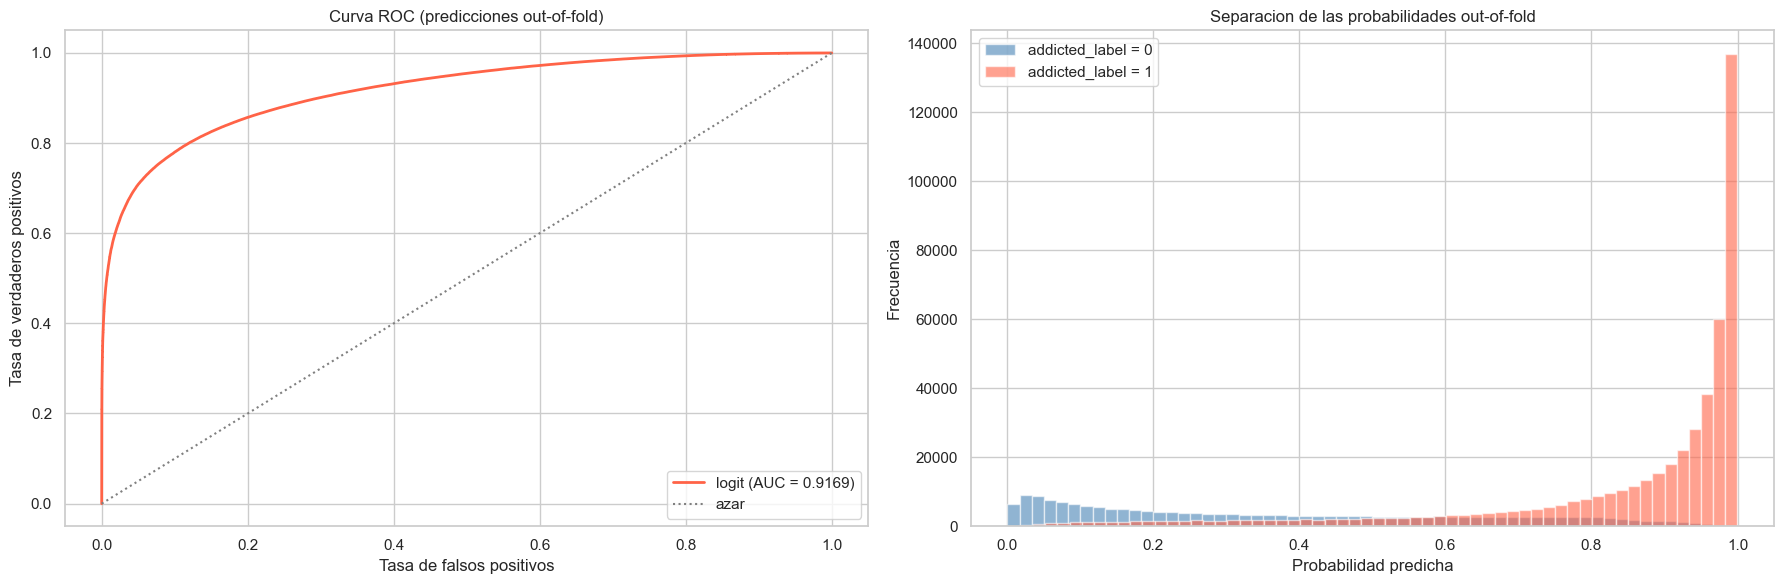

In [5]:
num_cols, cat_cols = configs[MEJOR]
features = num_cols + cat_cols

oof = cross_val_predict(construir_pipeline(num_cols, cat_cols), train[features], y,
                        cv=skf, method="predict_proba")[:, 1]
auc_oof = roc_auc_score(y, oof)
print(f"AUC out-of-fold: {auc_oof:.5f}")

fpr, tpr, _ = roc_curve(y, oof)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"logit (AUC = {auc_oof:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls=":", lw=1.5, label="azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC (predicciones out-of-fold)")
axes[0].legend(loc="lower right")
for cls, color in [(0, "steelblue"), (1, "tomato")]:
    axes[1].hist(oof[y == cls], bins=60, alpha=0.6, color=color,
                 label=f"addicted_label = {cls}")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Separacion de las probabilidades out-of-fold")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Modelo Final — Entrenamiento sobre todo el Train

In [6]:
modelo_final = construir_pipeline(num_cols, cat_cols)
modelo_final.fit(train[features], y)
print(f"Modelo final entrenado sobre {len(train):,} filas y {len(features)} features de entrada.")

Modelo final entrenado sobre 691,369 filas y 19 features de entrada.


## 6. Coeficientes del Modelo

Con las numéricas estandarizadas los coeficientes son comparables entre sí: cada uno es el cambio en
el log-odds ante **un desvío estándar** de la variable. Es la ventaja del logit frente a un modelo de
árboles.

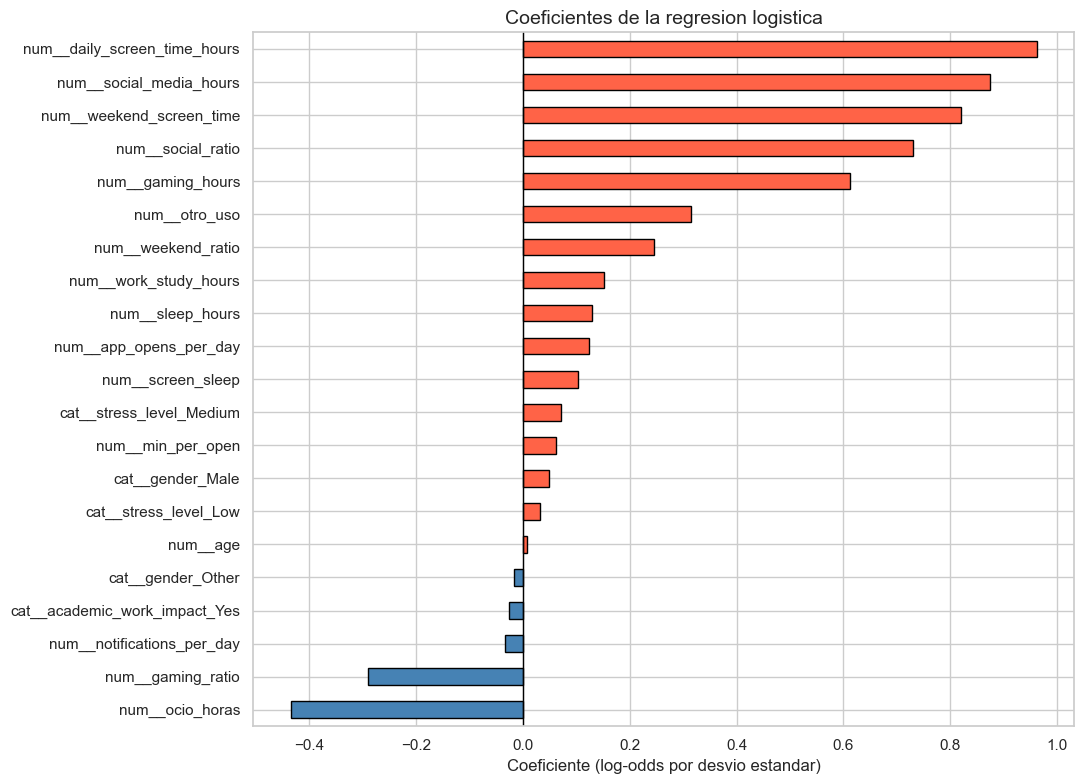

Top 10 por magnitud:
num__daily_screen_time_hours    0.9618
num__social_media_hours         0.8737
num__weekend_screen_time        0.8202
num__social_ratio               0.7304
num__gaming_hours               0.6125
num__ocio_horas                -0.4354
num__otro_uso                   0.3148
num__gaming_ratio              -0.2909
num__weekend_ratio              0.2448
num__work_study_hours           0.1514


In [7]:
nombres = modelo_final.named_steps["pre"].get_feature_names_out()
coefs   = pd.Series(modelo_final.named_steps["clf"].coef_[0], index=nombres).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
coefs.plot.barh(ax=ax, color=["steelblue" if v < 0 else "tomato" for v in coefs],
                edgecolor="black")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Coeficiente (log-odds por desvio estandar)")
ax.set_title("Coeficientes de la regresion logistica", fontsize=14)
plt.tight_layout()
plt.show()

print("Top 10 por magnitud:")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10).round(4).to_string())

## 7. Predicción sobre Test y Submission

In [8]:
proba_test = modelo_final.predict_proba(test[features])[:, 1]

submission = pd.DataFrame({"id": test["id"], TARGET: proba_test})
submission.to_csv("../submissions/2_logit_submission.csv", index=False)

print(f"Submission escrita: ../submissions/2_logit_submission.csv ({len(submission):,} filas)")
print(submission.head().to_string(index=False))
print(f"\nProbabilidad media predicha: {proba_test.mean():.4f}"
      f"  (tasa base en train: {y.mean():.4f})")

Submission escrita: ../submissions/2_logit_submission.csv (296,302 filas)
    id  addicted_label
691369        0.950958
691370        0.836565
691371        0.976018
691372        0.908601
691373        0.983426

Probabilidad media predicha: 0.7073  (tasa base en train: 0.7094)


In [9]:
# Chequeo de sanidad contra sample_submission (formato e ids)
sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "los ids no estan alineados"
assert submission[TARGET].between(0, 1).all(), "hay probabilidades fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos en la prediccion"
print("Chequeos OK — submission lista para enviar.")

Chequeos OK — submission lista para enviar.


## 8. Envío a Kaggle vía API

Las dos celdas siguientes **no fueron ejecutadas**; quedan listas para correr a mano. En este equipo
la CLI de Kaggle falla con `CERTIFICATE_VERIFY_FAILED` contra `api.kaggle.com` — el workaround del
bundle de certificados está en `Episode 6 - Predicting Stellar Class/notebook/3_catboost.ipynb`.

In [10]:
COMPETITION = "playground-series-s6e8"
FILE        = "../submissions/2_logit_submission.csv"
MSG         = f"Logit - crudas + derivadas - CV AUC={cv_mean:.5f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Smartphone Addiction



  0%|          | 0.00/7.66M [00:00<?, ?B/s]
  0%|          | 16.0k/7.66M [00:00<01:06, 121kB/s]
  7%|▋         | 528k/7.66M [00:00<00:07, 1.02MB/s]
  8%|▊         | 608k/7.66M [00:00<00:10, 685kB/s] 
 54%|█████▍    | 4.12M/7.66M [00:00<00:00, 7.09MB/s]
100%|██████████| 7.66M/7.66M [00:02<00:00, 3.94MB/s]


In [11]:
# Score publico del envio (esperar unos segundos a que Kaggle lo puntue)
!kaggle competitions submissions -c playground-series-s6e8

     ref  fileName                date                        description                                  status                    publicScore  privateScore  
--------  ----------------------  --------------------------  -------------------------------------------  ------------------------  -----------  ------------  
55393493  2_logit_submission.csv  2026-08-10 01:23:28.337000  Logit - crudas + derivadas - CV AUC=0.91687  SubmissionStatus.PENDING                             


## 9. Conclusiones

- **CV AUC = 0,91687** con `crudas + derivadas` (5-fold estratificado, desvío 0,00074 entre folds). El
  AUC out-of-fold da 0,91686, prácticamente idéntico, así que la estimación es estable.
- **Las derivadas sí aportan**: +0,0054 sobre las features crudas (0,91145 → 0,91687). Es un matiz
  interesante frente al EDA, donde los ratios correlacionaban **menos** que las horas crudas: en un
  modelo lineal los cocientes le dan acceso a combinaciones no lineales que por sí solo no puede
  construir.
- **El piso queda lejos**: `daily_screen_time_hours` sola rinde 0,86537; el modelo completo le suma
  +0,051 de AUC.
- **La imputación tiene un costo medible**: esa misma variable daba AUC 0,890 en el EDA midiendo sólo
  las filas donde está presente, pero 0,865 en CV cuando su 13,86 % de nulos se rellena con la
  mediana. Es el precio de que un modelo lineal no pueda tratar los NaN de forma nativa.
- **Los coeficientes no son interpretables de a uno**: al convivir `ocio_horas` con sus dos
  componentes (`social_media_hours` y `gaming_hours`), la colinealidad reparte el efecto y
  `ocio_horas` termina con signo **negativo** (−0,4354) pese a correlacionar +0,53 con el target. Para
  leer efectos individuales hay que mirar la configuración B, sin derivadas.
- **El ordenamiento por magnitud es razonable**: `daily_screen_time_hours` (0,96),
  `social_media_hours` (0,87), `weekend_screen_time` (0,82) y `social_ratio` (0,73) encabezan, en
  línea con lo que había mostrado el EDA.
- **Submission sin señales de shift**: la probabilidad media predicha sobre test es 0,7073, muy cerca
  de la tasa base de train (0,7094).
- **Score público en Kaggle: 0,91909**, contra un CV de 0,91687. El leaderboard da ~0,002 por encima,
  así que la validación cruzada es un proxy fiable y levemente conservador — se puede confiar en ella
  para decidir entre modelos sin gastar envíos.
- **Próximo paso**: gradient boosting (LightGBM / CatBoost) con NaN nativos. Que agregar cocientes a
  mano haya valido +0,005 sugiere que queda estructura no lineal e interacciones que un modelo de
  árboles captura sin necesidad de construirlas explícitamente.

> Confirmado en `3_xgboost.ipynb`: XGBoost llega a **CV AUC 0,96478** sin tuning, +0,048 sobre este
> baseline.